In [ ]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import math
from collections import Counter, defaultdict

# Set up paths and import katspace modules
drive_dir = Path("../")
module_path = os.path.abspath(str(drive_dir))
sys.path.insert(0, module_path)

import katspace
import katspace.core
import katspace.data
import katspace.plot
import importlib
for mod in ["katspace.core", "katspace.data", "katspace.plot"]:
    importlib.reload(sys.modules[mod])

from katspace.data import non_empty_labels_from_iter
from katspace.plot import beginning_history_preprocess, prep_plot_compare_new, plot_compare, calculate_ratios2
from katspace.data import chunker


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/local/Cellar/python@3.10/3.10.19_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/local/Cellar/python@3.10/3.10.19_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/katrinrohrbacher/Meine Ablage/LLM_worldbuilding/nb-venv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_in

In [4]:
# File paths
data_dir = Path(drive_dir, "data-test/")
gutenberg_json_path = Path("gutenberg_results_EN.json")
aggregated_parquet_path = Path("combined_results_En.parquet")

In [5]:
# --- Load LLM results from parquet ---
llm_df = pd.read_parquet("combined_results_En.parquet").reset_index()

llm_df["source"] = "llm"
llm_df = llm_df.rename(columns={"experiment_name": "experiment"})

In [6]:
# --- Load Gutenberg JSON results ---
def load_json_to_df(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows = []
    for entry in data:
        filename = entry["filename"]
        title = entry["title"]
        sentence = entry["sentence"]
        label = entry["prediction"]["label"]
        score = entry["prediction"]["score"]
        rows.append((filename, title, sentence, label, score))
    df = pd.DataFrame(rows, columns=["filename", "title", "sentence", "label", "score"])
    df["sentence_id"] = df.groupby("filename").cumcount()
    df["source"] = "gutenberg"
    return df

# Load both human JSON files
json_df1 = load_json_to_df("gutenberg_results_EN.json")
json_df2 = load_json_to_df("gutenberg_results_missing_files_EN.json")
# Merge the two dataframes
json_df = pd.concat([json_df1, json_df2], ignore_index=True)

# Rename columns to match Parquet file
json_df = json_df.rename(columns={"title": "document_id", "sentence": "sentence", "label": "label"})
json_df["experiment_name"] = "Human"
json_df["experiment"] = "Human"  
json_df["cumulative_word_count"] = None 
json_df["source"] = "gutenberg"

In [7]:
# --- Combine ---
combined_df = pd.concat([
    llm_df[["document_id","sentence_id","label","score","experiment","cumulative_word_count","sentence"]],
    json_df[["document_id","sentence_id","label","score","experiment","cumulative_word_count","sentence"]]
], ignore_index=True)

print(combined_df.head())

  document_id  sentence_id    label     score              experiment  \
0       10007            0  LABEL_4  0.751264  Narrative_En_Llama_70B   
1       10007            1  LABEL_4  0.790344  Narrative_En_Llama_70B   
2       10007            2  LABEL_4  0.892886  Narrative_En_Llama_70B   
3       10007            3  LABEL_4  0.855459  Narrative_En_Llama_70B   
4       10007            4  LABEL_4  0.863766  Narrative_En_Llama_70B   

  cumulative_word_count                                           sentence  
0                    35  Upon a paper attached to the Narrative which f...  
1                    79  He assures us that he has, with the most scrup...  
2                   119  The narrative itself is a most singular and ex...  
3                   151  This patient, a young woman of remarkable beau...  
4                   188  She had been, for many years, the victim of a ...  


In [8]:
# --- Map experiment names to nicer labels ---
name_map = {
    "Narrative_En_Llama_70B": "LLaMA 3.3",
    "Narrative_En_Gemma_3_27B": "Gemma 3",
    "Narrative_En_Mistral_3.2_24B": "Mistral 3.2",
    "Narrative_En_ChatGPT_Batch_V2": "GPT 4.1",  
    "Human": "Human"    
}

combined_df["experiment"] = combined_df["experiment"].replace(name_map)



In [9]:
label_map = {
    "LABEL_0": "perceived_space",
    "LABEL_1": "action_space",
    "LABEL_2": "visual_space",
    "LABEL_3": "descriptive_space",
    "LABEL_4": "no_space",
    "no_space": "no_space",
    "action_space": "action_space",
    "descriptive_space": "descriptive_space",
    "perceived_space": "perceived_space",
    "visual_space": "visual_space"
}

combined_df["label"] = combined_df["label"].map(label_map)
print("Labels after mapping:", combined_df["label"].unique())


Labels after mapping: ['no_space' 'action_space' 'perceived_space' 'visual_space'
 'descriptive_space']


In [10]:
# --- Equal-chunking utility ---
def split_into_equal_chunks(lst, n_chunks):
    """Split a list into n_chunks approximately equal-size contiguous chunks."""
    chunk_sizes = [len(lst) // n_chunks] * n_chunks
    for i in range(len(lst) % n_chunks):
        chunk_sizes[i] += 1
    chunks = []
    idx = 0
    for size in chunk_sizes:
        chunks.append(lst[idx:idx+size])
        idx += size
    return chunks

In [11]:
# --- Main chunk and frequency calculation ---
def chunk_and_count_equal(combined_df, num_chunks, space_types=None):
    """
    For each document, divide full text into num_chunks equal parts, 
    count frequency of each space type per chunk, and normalize by sentences per chunk.
    """
    if space_types is None:
        space_types = ["perceived_space", "action_space", "visual_space", "descriptive_space", "no_space"]
    result = defaultdict(lambda: defaultdict(list))  # space_type -> model -> list of [freqs across chunks]

    for (doc_id, model), group in combined_df.groupby(["document_id", "experiment"]):
        group = group.sort_values("sentence_id")
        labels = group["label"].tolist()

        # Only consider texts with enough sentences for chosen chunking (at least num_chunks)
        if len(labels) < num_chunks:
            continue

        # equal contiguous chunks (each chunk: list of space type labels)
        label_chunks = split_into_equal_chunks(labels, num_chunks)
        chunk_lens = [len(chunk) for chunk in label_chunks]
        counters = [Counter(chunk) for chunk in label_chunks]

        for type_ in space_types:
            # For each chunk, compute normalized freq for that space type
            norm_freq = [counter.get(type_, 0)/length if length > 0 else 0 
                         for counter, length in zip(counters, chunk_lens)]
            result[type_][model].append(norm_freq)
            
        # NEW: add all_space as sum of the 4 types
        all_space_freq = [
            (counter.get("action_space", 0) + 
             counter.get("descriptive_space", 0) + 
             counter.get("perceived_space", 0) + 
             counter.get("visual_space", 0)) / length if length > 0 else 0
            for counter, length in zip(counters, chunk_lens)
        ]
        result["all_space"][model].append(all_space_freq)
        
    return result

In [26]:
num_chunks = 10
chunked_result = chunk_and_count_equal(combined_df, num_chunks=num_chunks)

In [ ]:
# --- Load German combined_df ---
ger_llm_df = pd.read_parquet("combined_results_Ger.parquet").reset_index()
if "experiment_name" in ger_llm_df.columns and "experiment" in ger_llm_df.columns:
    ger_llm_df = ger_llm_df.drop(columns=["experiment_name"])

ger_json_df = pd.concat([
    load_json_to_df("gutenberg_results.json"),
    load_json_to_df("gutenberg_results_missing_files_de.json"),
    load_json_to_df("gutenberg_results_missing_files_de_2.json"),
], ignore_index=True)
ger_json_df = ger_json_df.rename(columns={"title": "document_id"})
ger_json_df["experiment"] = "Human"
ger_json_df["cumulative_word_count"] = None

ger_combined_df = pd.concat([
    ger_llm_df[["document_id", "sentence_id", "label", "score", "experiment", "cumulative_word_count", "sentence"]],
    ger_json_df[["document_id", "sentence_id", "label", "score", "experiment", "cumulative_word_count", "sentence"]],
], ignore_index=True)

ger_name_map = {
    "Narrative_Ger_Llama_70B_final": "LLaMA 3.3",
    "Narrative_Ger_Gemma_3_27B_final": "Gemma 3",
    "Narrative_Ger_Mistral_3.2_24B_final": "Mistral 3.2",
    "Narrative_Ger_ChatGPT_Batch_V2": "GPT 4.1",
    "Human": "Human"
}
ger_combined_df["experiment"] = ger_combined_df["experiment"].replace(ger_name_map)

In [17]:
# --- Tag each dataframe with its language and merge ---
eng_df = combined_df.copy()
eng_df["language"] = "English"

ger_df = ger_combined_df.copy()
ger_df["language"] = "German"

bilingual_df = pd.concat([eng_df, ger_df], ignore_index=True)

/var/folders/j9/xtms31j167b3r2qv8frj6vf80000gn/T/ipykernel_23389/3486731770.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_order, rotation=20, ha="right")
/var/folders/j9/xtms31j167b3r2qv8frj6vf80000gn/T/ipykernel_23389/3486731770.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_order, rotation=20, ha="right")
/var/folders/j9/xtms31j167b3r2qv8frj6vf80000gn/T/ipykernel_23389/3486731770.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_order, rotation=20, ha="right")
/var/folders/j9/xtms31j167b3r2qv8frj6vf80000gn/T/ipykernel_23389/3486731770.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or u

Saved to figure_opening_window.pdf


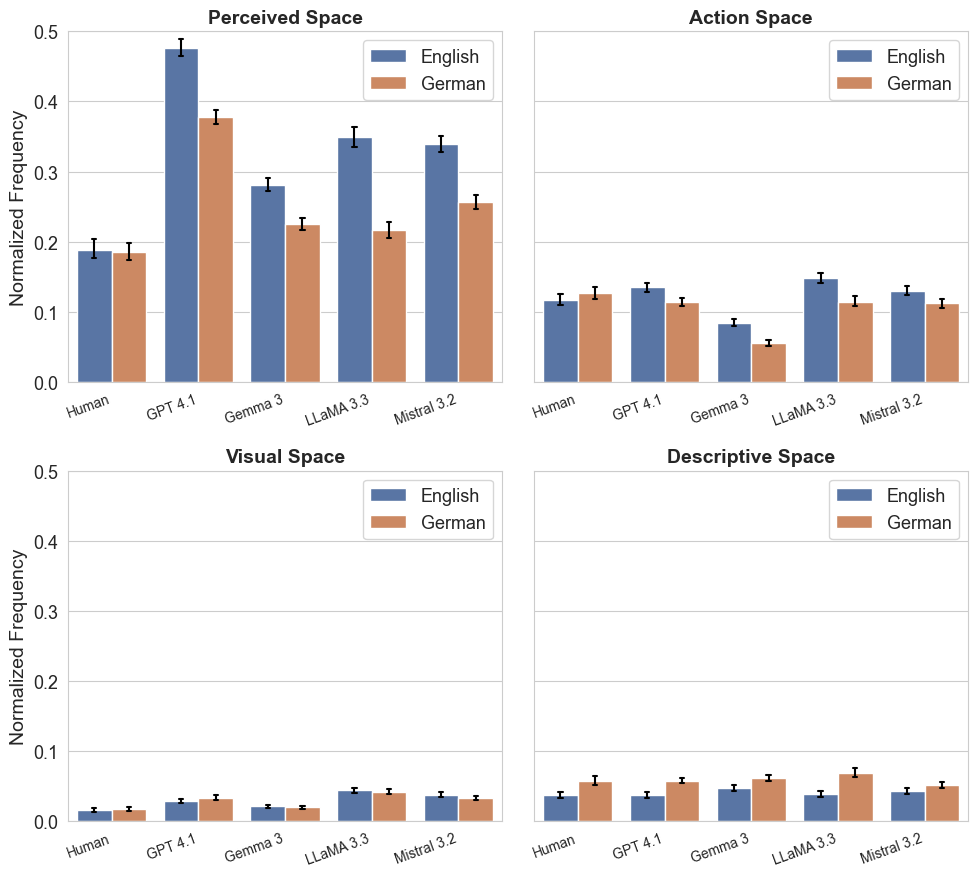

In [18]:
def plot_opening_window_5panels_hue_lang_pub(bilingual_df, window=15, space_types=None,
                                              include_all_space=False, save_path=None,
                                              figsize=(10, 9), ymax=0.5):
    if space_types is None:
        space_types = ["perceived_space", "action_space", "visual_space", "descriptive_space"]

    opening_df = (
        bilingual_df
        .sort_values("sentence_id")
        .groupby(["document_id", "experiment", "language"], group_keys=False)
        .head(window)
    )

    rows = []
    for (doc_id, model, lang), group in opening_df.groupby(["document_id", "experiment", "language"]):
        n = len(group)
        if n == 0:
            continue
        counts = group["label"].value_counts()
        for space_type in space_types:
            rows.append({
                "document_id": doc_id, "experiment": model, "language": lang,
                "space_type": space_type, "norm_freq": counts.get(space_type, 0) / n
            })
        if include_all_space:
            all_count = sum(counts.get(s, 0) for s in space_types if s != "no_space")
            rows.append({
                "document_id": doc_id, "experiment": model, "language": lang,
                "space_type": "all_space", "norm_freq": all_count / n
            })

    result_df = pd.DataFrame(rows)
    space_order = space_types + (["all_space"] if include_all_space else [])
    lang_order = ["English", "German"]
    lang_palette = {"English": "#4C72B0", "German": "#DD8452"}
    model_order = ["Human", "GPT 4.1", "Gemma 3", "LLaMA 3.3", "Mistral 3.2"]

    sns.set_style("whitegrid")
    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 10,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
    })
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharey=True)
    axes_flat = axes.flatten()

    for i, space_type in enumerate(space_order):
        ax = axes_flat[i]
        sub = result_df[result_df["space_type"] == space_type]

        sns.barplot(
            data=sub, x="experiment", y="norm_freq",
            hue="language",
            hue_order=lang_order,
            order=model_order,
            palette=lang_palette,
            errorbar=("ci", 95),
            err_kws={"color": "black", "linewidth": 1.5},
            capsize=0.1,
            ax=ax
        )

        ax.set_title(space_type.replace("_", " ").title(), fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Normalized Frequency" if i % 2 == 0 else "")
        ax.set_ylim(0, ymax)
        ax.set_xticklabels(model_order, rotation=20, ha="right")
        ax.get_legend().remove()

    # Add legend inside every panel
    handles, labels = axes_flat[0].get_legend_handles_labels()
    for ax in axes_flat[:len(space_order)]:
        ax.legend(handles, labels, title=None, loc="upper right",
                  fontsize=13, frameon=True)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

plot_opening_window_5panels_hue_lang_pub(bilingual_df, window=15, save_path="figure_opening_window.pdf")

In [19]:
# --- Setup for graphs 1–6: convert chunked results to tidy format ---
# Run this cell before running graphs 1–6 below.
ger_chunked_result = chunk_and_count_equal(ger_combined_df, num_chunks=10)

def chunked_to_tidy(result_dict, num_chunks=10):
    rows = []
    for space_type, model_dict in result_dict.items():
        for model, sequences in model_dict.items():
            for seq in sequences:
                if len(seq) != num_chunks:
                    continue
                for chunk_idx, val in enumerate(seq, 1):
                    rows.append({"space_type": space_type, "model": model,
                                 "chunk": chunk_idx, "freq": val})
    return pd.DataFrame(rows)

eng_tidy = chunked_to_tidy(chunked_result)
ger_tidy = chunked_to_tidy(ger_chunked_result)
#print(f"eng_tidy: {len(eng_tidy)} rows | ger_tidy: {len(ger_tidy)} rows")

In [20]:
# Average sentences in section 1 per model
section1 = (
    combined_df.sort_values("sentence_id")
    .groupby(["document_id", "experiment"], group_keys=False)
    .apply(lambda g: g.head(len(g) // num_chunks))
    .groupby(["document_id", "experiment"])["sentence_id"]
    .count()
    .reset_index()
    .rename(columns={"sentence_id": "sentences_in_section1"})
)

summary_s1 = (
    section1.groupby("experiment")["sentences_in_section1"]
    .agg(mean="mean", std="std", min="min", max="max")
    .round(1)
)
print(summary_s1)


             mean   std  min  max
experiment                       
GPT 4.1      52.8   7.6   22   78
Gemma 3      81.2  43.1   36  350
Human        43.7  10.7   15  115
LLaMA 3.3    56.0   9.4   18   89
Mistral 3.2  56.8  11.1   24  105


/var/folders/j9/xtms31j167b3r2qv8frj6vf80000gn/T/ipykernel_23389/3838104653.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.head(len(g) // num_chunks))


Saved to figure_deviation_from_human.pdf


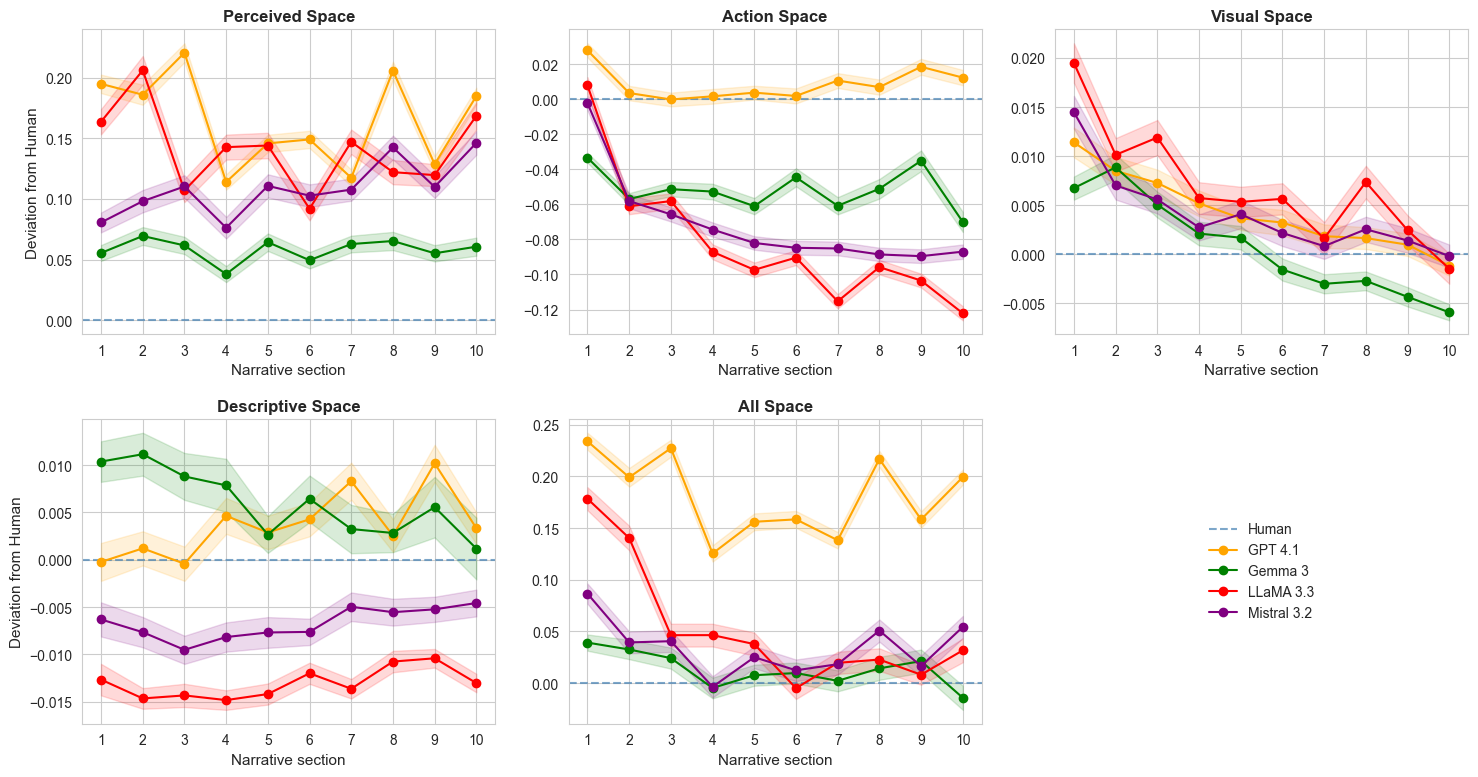

In [23]:
# --- Deviation from human baseline across narrative ---
def plot_deviation_from_human(tidy_df, num_chunks=10, space_types=None, save_path=None):
    if space_types is None:
        space_types = ["perceived_space", "action_space", "visual_space",
                       "descriptive_space", "no_space", "all_space"]

    ai_models = ["GPT 4.1", "Gemma 3", "LLaMA 3.3", "Mistral 3.2"]
    model_colors = {"GPT 4.1": "orange", "Gemma 3": "green",
                    "LLaMA 3.3": "red", "Mistral 3.2": "purple"}

    human_mean = (
        tidy_df[tidy_df["model"] == "Human"]
        .groupby(["space_type", "chunk"])["freq"].mean()
    )

    # Compute deviation per document, then aggregate mean + SE
    ai_docs = tidy_df[tidy_df["model"].isin(ai_models)].copy()
    ai_docs["deviation"] = ai_docs.apply(
        lambda r: r["freq"] - human_mean.get((r["space_type"], r["chunk"]), 0), axis=1
    )
    grouped = ai_docs.groupby(["space_type", "model", "chunk"])["deviation"]
    ai_agg = grouped.agg(mean="mean", se=lambda x: x.std() / len(x) ** 0.5).reset_index()

    ncols = 3
    nrows = math.ceil(len(space_types) / ncols)
    chunk_ids = np.arange(1, num_chunks + 1)

    sns.set_style("whitegrid")
    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
    })
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = axes.flatten()

    for i, space_type in enumerate(space_types):
        ax = axes_flat[i]
        ax.axhline(0, color="steelblue", linestyle="--", linewidth=1.5, alpha=0.7, label="Human")
        for model in ai_models:
            sub = ai_agg[(ai_agg["space_type"] == space_type) &
                         (ai_agg["model"] == model)].sort_values("chunk")
            ax.plot(sub["chunk"], sub["mean"], marker="o",
                    color=model_colors[model], label=model, linewidth=1.5)
            ax.fill_between(sub["chunk"],
                            sub["mean"] - 1.96 * sub["se"],
                            sub["mean"] + 1.96 * sub["se"],
                            color=model_colors[model], alpha=0.15)
        ax.set_title(space_type.replace("_", " ").title(), fontsize=12, fontweight="bold")
        ax.set_xlabel("Narrative section", fontsize=11)
        ax.set_ylabel("Deviation from Human" if i % ncols == 0 else "", fontsize=11)
        ax.tick_params(axis="both", labelsize=10)
        ax.set_xticks(chunk_ids)

    legend_ax = axes_flat[len(space_types)]
    legend_ax.set_visible(True)
    legend_ax.axis("off")
    handles, labels = axes_flat[0].get_legend_handles_labels()
    legend_ax.legend(handles, labels, fontsize=10, frameon=False, loc="center")

    for j in range(len(space_types) + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

plot_deviation_from_human(eng_tidy, space_types=["perceived_space", "action_space",
                                                  "visual_space", "descriptive_space", "all_space"],
                          save_path="figure_deviation_from_human.pdf")

Saved to figure_arc_spotlight.pdf


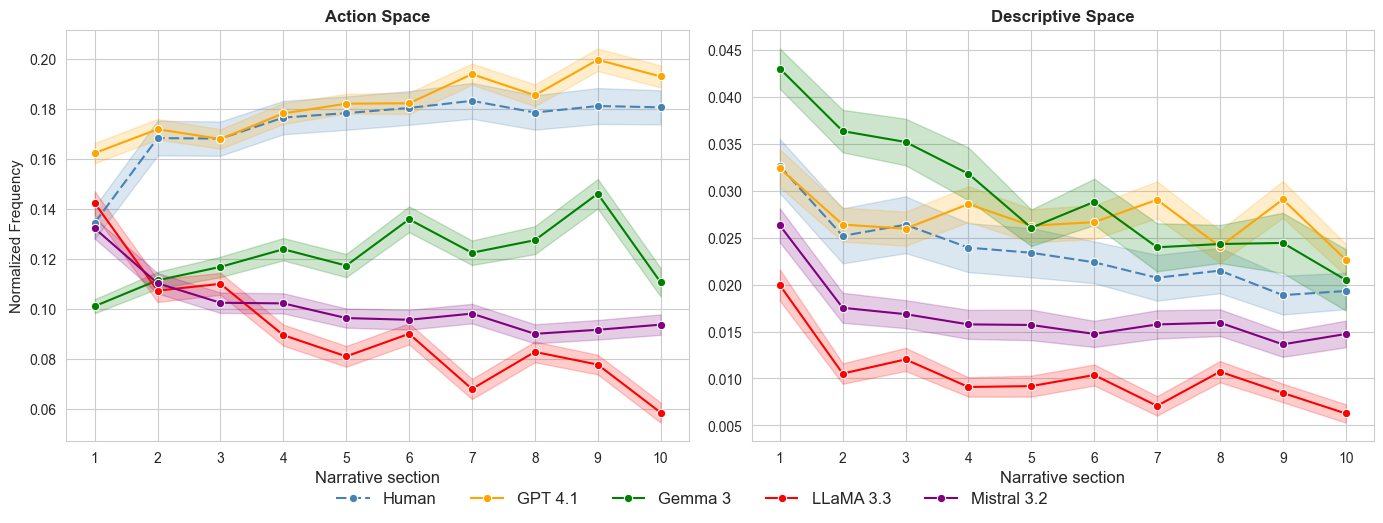

In [24]:
# --- Graph 2: Narrative arc spotlight (one panel per space type) ---
def plot_arc_spotlight(tidy_df, space_types=None, num_chunks=10, language="English", save_path=None):
    if space_types is None:
        space_types = ["action_space"]

    model_order = ["Human", "GPT 4.1", "Gemma 3", "LLaMA 3.3", "Mistral 3.2"]
    model_colors = {"Human": "steelblue", "GPT 4.1": "orange", "Gemma 3": "green",
                    "LLaMA 3.3": "red", "Mistral 3.2": "purple"}
    dashes_map = {"Human": (5, 2), "GPT 4.1": (1, 0), "Gemma 3": (1, 0),
                  "LLaMA 3.3": (1, 0), "Mistral 3.2": (1, 0)}

    sns.set_style("whitegrid")
    plt.rcParams.update({"font.size": 12})
    fig, axes = plt.subplots(1, len(space_types), figsize=(7 * len(space_types), 5), sharey=False)
    if len(space_types) == 1:
        axes = [axes]

    for ax, space_type in zip(axes, space_types):
        sub = tidy_df[tidy_df["space_type"] == space_type].rename(
            columns={"model": "Model", "chunk": "Chunk", "freq": "Frequency"}
        )
        sns.lineplot(
            data=sub, x="Chunk", y="Frequency",
            hue="Model", style="Model",
            hue_order=model_order, style_order=model_order,
            palette=model_colors, dashes=dashes_map,
            markers={m: "o" for m in model_order},
            errorbar=("se", 1.96), ax=ax
        )
        ax.set_title(space_type.replace("_", " ").title(), fontsize=12, fontweight="bold")
        ax.set_xlabel("Narrative section", fontsize=12)
        ax.set_ylabel("Normalized Frequency" if ax is axes[0] else "", fontsize=11)
        ax.tick_params(axis="both", labelsize=10)
        ax.set_xticks(np.arange(1, num_chunks + 1))
        ax.get_legend().remove()

    # Shared legend below — adjust bbox_to_anchor y to move legend up/down
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title=None, fontsize=12,
               loc="lower center", ncol=len(model_order), bbox_to_anchor=(0.5, -0.06),
               frameon=False)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

plot_arc_spotlight(eng_tidy, space_types=["action_space", "descriptive_space"],
                   language="English", save_path="figure_arc_spotlight.pdf")

Saved to figure_bilingual_deviation.pdf


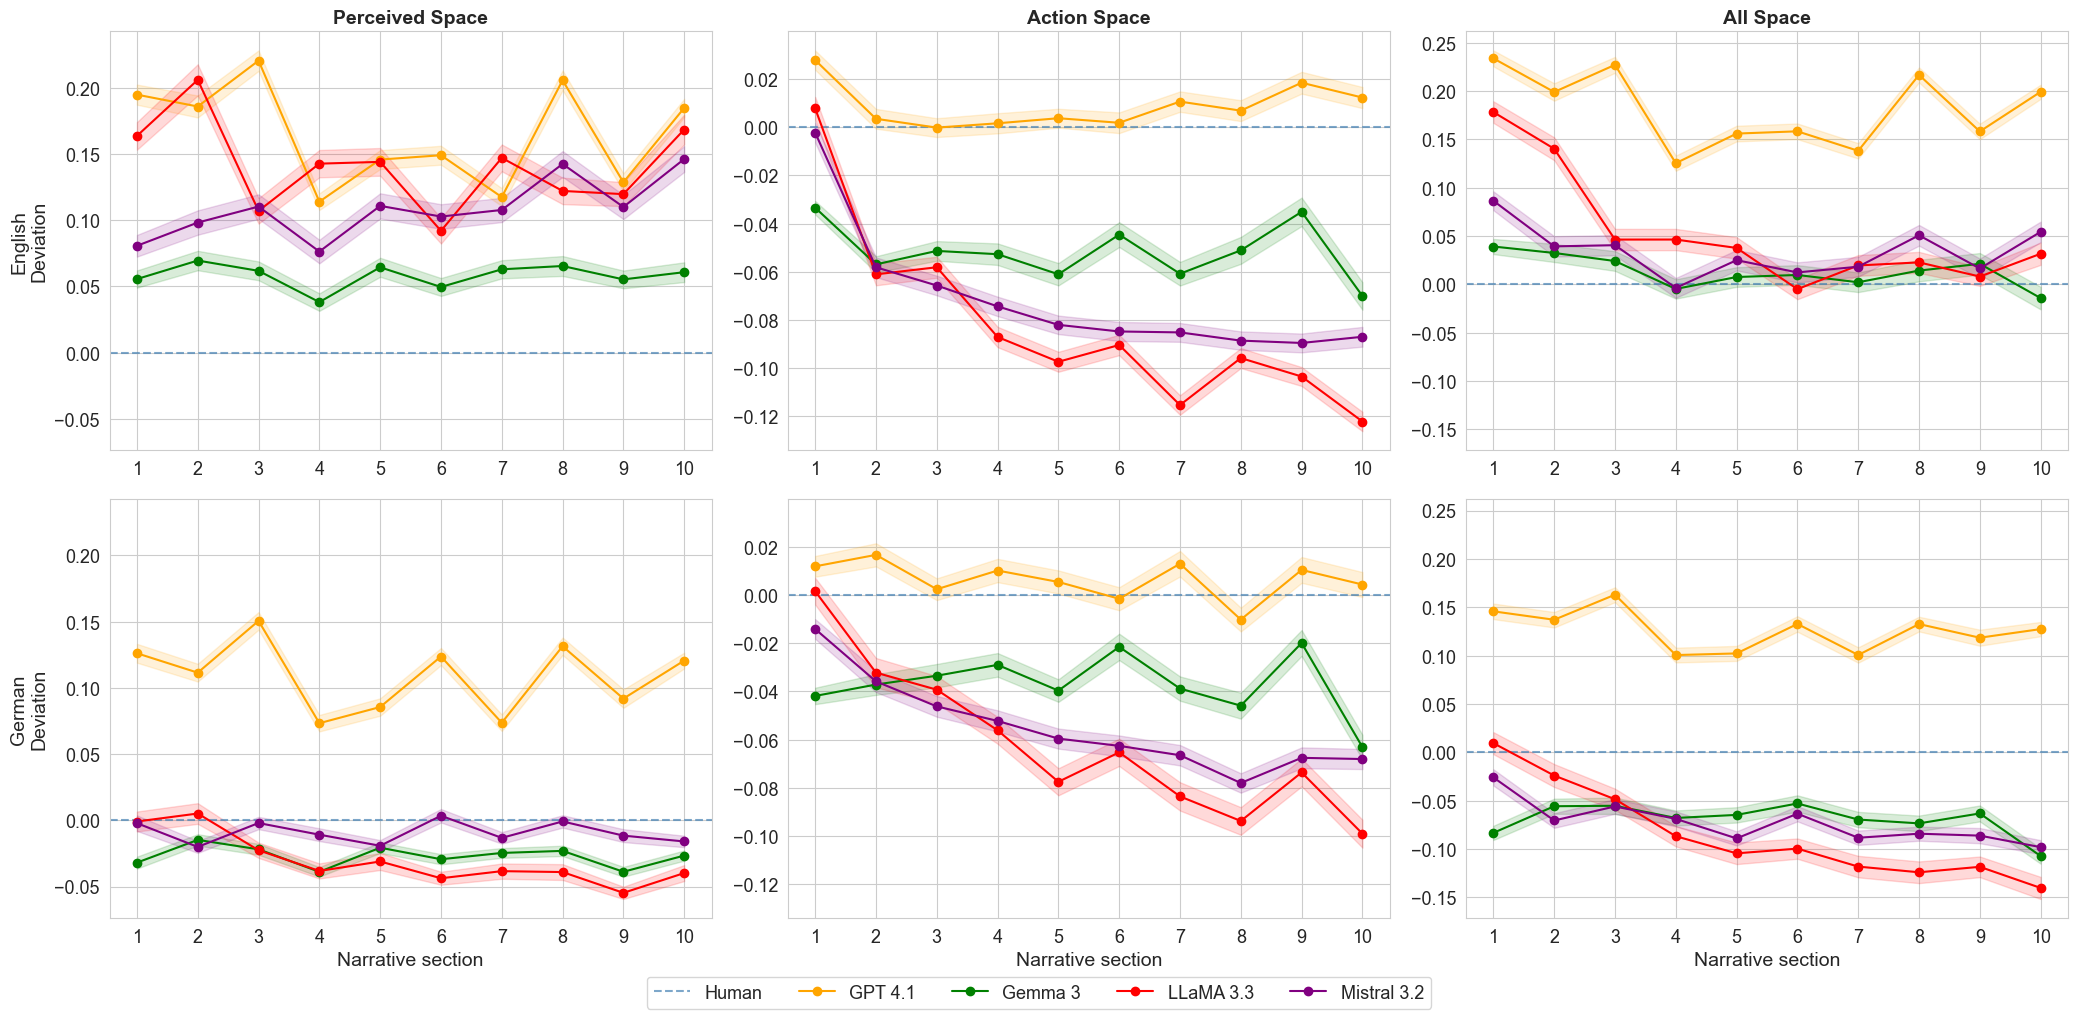

In [25]:
# --- Cross-language: Bilingual deviation from human baseline ---

def plot_bilingual_deviation(eng_tidy, ger_tidy, num_chunks=10,
                              space_types=None, save_path=None):
    if space_types is None:
        space_types = ["perceived_space", "action_space", "all_space"]

    ai_models    = ["GPT 4.1", "Gemma 3", "LLaMA 3.3", "Mistral 3.2"]
    model_colors = {"GPT 4.1": "orange", "Gemma 3": "green",
                    "LLaMA 3.3": "red", "Mistral 3.2": "purple"}
    chunk_ids    = np.arange(1, num_chunks + 1)
    languages    = ["English", "German"]
    lang_dfs     = {"English": eng_tidy, "German": ger_tidy}
    n_cats       = len(space_types)

    sns.set_style("whitegrid")
    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
    })
    # 2 rows (languages) × n_cats columns (space types)
    fig, axes = plt.subplots(2, n_cats,
                             figsize=(7 * n_cats, 10),
                             sharey="col")

    for j, lang in enumerate(languages):
        tidy = lang_dfs[lang]

        human_mean = (
            tidy[tidy["model"] == "Human"]
            .groupby(["space_type", "chunk"])["freq"].mean()
        )

        ai_docs = tidy[tidy["model"].isin(ai_models)].copy()
        ai_docs["deviation"] = ai_docs.apply(
            lambda r: r["freq"] - human_mean.get(
                (r["space_type"], r["chunk"]), 0), axis=1
        )
        grouped = ai_docs.groupby(["space_type", "model", "chunk"])["deviation"]
        ai_agg = grouped.agg(
            mean="mean", se=lambda x: x.std() / len(x) ** 0.5
        ).reset_index()

        for i, space_type in enumerate(space_types):
            ax = axes[j, i]

            ax.axhline(0, color="steelblue", linestyle="--",
                       linewidth=1.5, alpha=0.7,
                       label="Human" if (i == 0 and j == 0) else "_")

            for model in ai_models:
                sub = ai_agg[
                    (ai_agg["space_type"] == space_type) &
                    (ai_agg["model"] == model)
                ].sort_values("chunk")
                ax.plot(sub["chunk"], sub["mean"],
                        marker="o", linewidth=1.5,
                        color=model_colors[model],
                        label=model if (i == 0 and j == 0) else "_")
                ax.fill_between(sub["chunk"],
                                sub["mean"] - 1.96 * sub["se"],
                                sub["mean"] + 1.96 * sub["se"],
                                color=model_colors[model], alpha=0.15)

            if j == 0:
                ax.set_title(space_type.replace("_", " ").title(), fontweight="bold")
            ax.set_ylabel(lang + "\nDeviation" if i == 0 else "")
            ax.set_xlabel("Narrative section" if j == 1 else "")
            ax.set_xticks(chunk_ids)

    # Shared legend below — adjust bbox_to_anchor y to move legend up/down
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, title=None, loc="lower center",
               ncol=len(ai_models) + 1,
               bbox_to_anchor=(0.5, -0.03))
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.07)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

plot_bilingual_deviation(eng_tidy, ger_tidy, save_path="figure_bilingual_deviation.pdf")